# Counting Environment Demo

This notebook demonstrates the Counting environment where you mark and count objects in images.

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [3]:
env = gym.make("counting/easy", seed=42)
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")
print(f"Min count: {env.unwrapped.min_count}, Max count: {env.unwrapped.max_count}")

Loading LVIS annotation file...
Filtering valid samples...
Sorting and applying data chunk...
LVIS Counting Environment Statistics:
  Total images: 100170
  Valid samples (min=2, max=20, exhaustive=True): 71055
  Filtered out: 29115
Action Space: FuncConditional(['mark', 'undo', 'guess', 'stop'])
Available actions: ['mark', 'undo', 'guess', 'stop']
Min count: 2, Max count: 20


## 2. Reset and View Initial State

Observation shape: (640, 427, 3)
Category: sock


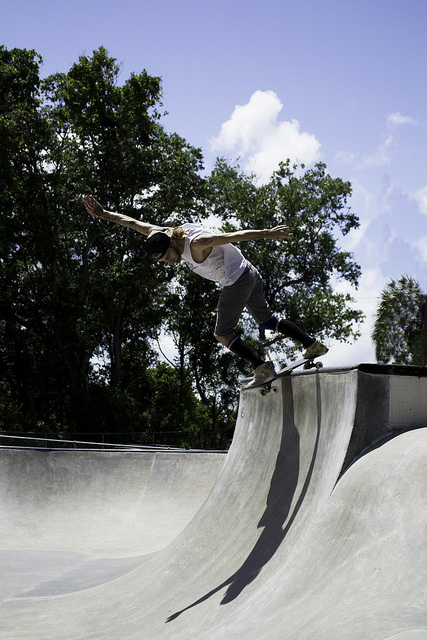


Task Prompt:
You are solving a sock-counting task. Count the number of sock in the image. You can place dots to mark instances and then record your final count.

Available actions:
1. 'mark': Place a dot at normalized coordinates. Format: `('mark', (x, y))` where x and y are normalized coordinates between 0.0 and 1.0.
2. 'undo': Remove your last placed dot. Format: `('undo', 'undo')`
3. 'guess': Record your count guess. Format: `('guess', N)` where N is an integer between 2 and 20.
4. 'stop': End the counting session. Format: `('stop', 'stop')`

Success: You succeed if your final count guess matches the true number of objects.

Please respond with exactly one action and its arguments in the specified format. For example:
- To mark a point: `('mark', (0.5, 0.3))`
- To undo: `('undo', 'undo')`
- To guess count: `('guess', 5)`
- To stop: `('stop', 'stop')`


In [5]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Category: {env.unwrapped.category_name}")

display(Image.fromarray(obs))
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions

Action: ('mark', (0.5, 0.5))
Current dots: 2


user/launch/current/gymnasium/spaces/box.py:423: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


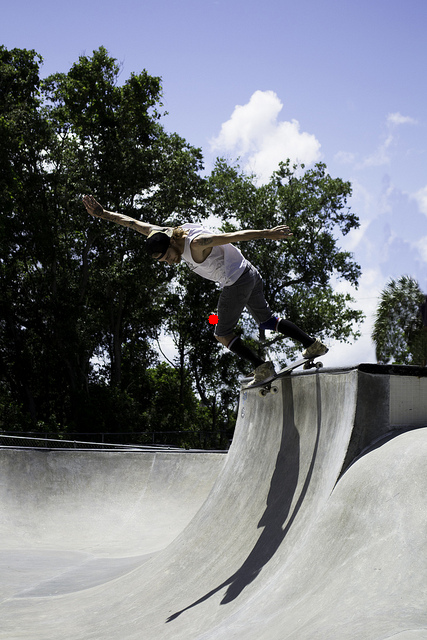

In [7]:
# Mark a point
action = "('mark', (0.5, 0.5))"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Current dots: {len(env.unwrapped.dots)}")
display(Image.fromarray(obs))

In [8]:
# Make a guess
action = f"('guess', {info['true_count']})"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Current guess: {info['current_guess']}")

# Stop
action = "('stop', 'stop')"
obs, reward, terminated, truncated, info = env.step(action)
print(f"\nAction: {action}")
print(f"Final reward: {reward}")
print(f"Terminated: {terminated}")

Action: ('guess', 2)
Current guess: 2

Action: ('stop', 'stop')
Final reward: 1.0
Terminated: True


## 4. Test Solver - Mark All Strategy

Loading LVIS annotation file...
Filtering valid samples...
Sorting and applying data chunk...
LVIS Counting Environment Statistics:
  Total images: 100170
  Valid samples (min=2, max=20, exhaustive=True): 71055
  Filtered out: 29115


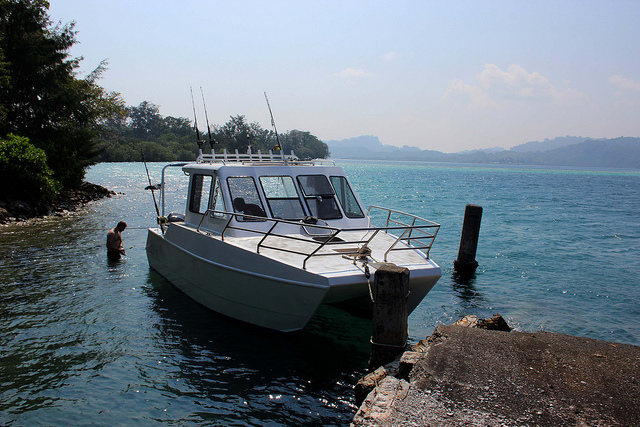


Solver generated 6 actions

✓ Episode finished! Reward: 1.0
Final guess: 4, True count: 4


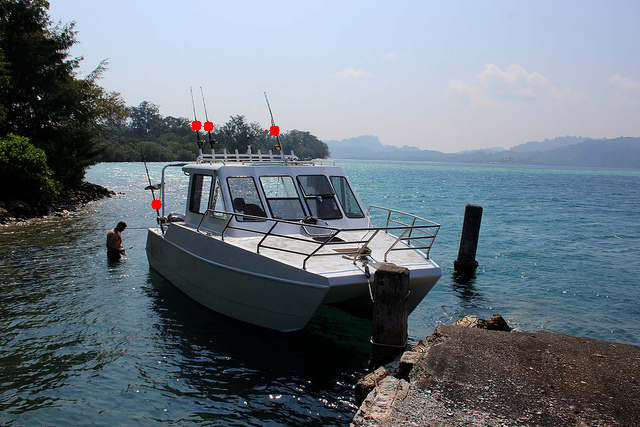

In [10]:
env = gym.make("counting/easy", seed=100)
obs, info = env.reset()
display(Image.fromarray(obs))

# Get solver actions (mark all objects)
actions = env.solve(strategy="mark_all")
print(f"\nSolver generated {len(actions)} actions")

# Execute all actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated:
        print(f"\n✓ Episode finished! Reward: {reward}")
        print(f"Final guess: {info['current_guess']}, True count: {info['true_count']}")
        display(Image.fromarray(obs))
        break

env.close()

## 5. Test Solver - Guess Only Strategy

In [13]:
env = gym.make("counting/easy", seed=200)
obs, info = env.reset()

# Get solver actions (just guess without marking)
actions = env.solve(strategy="guess_only")
print(f"Solver actions: {actions}")

for action in actions:
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated:
        print(f"Reward: {reward}")
        break

env.close()

Loading LVIS annotation file...


Filtering valid samples...
Sorting and applying data chunk...
LVIS Counting Environment Statistics:
  Total images: 100170
  Valid samples (min=2, max=20, exhaustive=True): 71055
  Filtered out: 29115
Solver actions: ["('guess', 3)", "('stop', 'stop')"]
Reward: 1.0


## 6. Test Hard Difficulty

Loading LVIS annotation file...
Filtering valid samples...
Sorting and applying data chunk...
LVIS Counting Environment Statistics:
  Total images: 100170
  Valid samples (min=5, max=30, exhaustive=True): 27468
  Filtered out: 72702
Hard difficulty - higher count range: 5 to 30


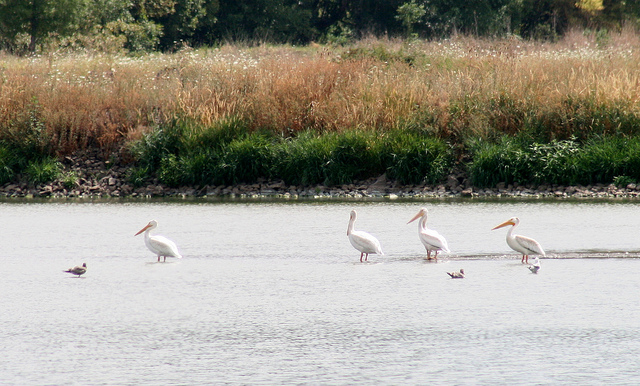

In [15]:
env_hard = gym.make("counting/hard", seed=42)
obs, info = env_hard.reset()
print(f"Hard difficulty - higher count range: {env_hard.unwrapped.min_count} to {env_hard.unwrapped.max_count}")
display(Image.fromarray(obs))

env_hard.close()